In [2]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# Carica il dataset
df = pd.read_csv('C:\\Users\\HP\\Desktop\\data_science\\primo_anno\\DSLab\\DS_Lab\\cleaned_df2.csv')

target = 'cyber_fraud_victim'
results = []

# Separiamo le variabili dal target
features = [col for col in df.columns if col != target and col != 'wght'] # Escludiamo i pesi

for col in features:
    # Rimuoviamo i NaN per il calcolo univariato
    temp_df = df[[col, target]].dropna()
    if temp_df.empty or len(temp_df[col].unique()) <= 1:
        continue
        
    col_type = temp_df[col].dtype
    p_value = np.nan
    test_used = ""
    
    # --- Test per Continue/Ordinali ---
    if pd.api.types.is_numeric_dtype(col_type):
        group0 = temp_df[temp_df[target] == 0][col]
        group1 = temp_df[temp_df[target] == 1][col]
        
        if len(group0) > 0 and len(group1) > 0:
            stat, p_value = mannwhitneyu(group0, group1, alternative='two-sided')
            test_used = "Mann-Whitney U"
            
    # --- Test per Categoriche ---
    else:
        contingency_table = pd.crosstab(temp_df[col], temp_df[target])
        # Eseguiamo il Chi-Quadro solo se la tabella ha senso
        if contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1:
            stat, p_value, dof, expected = chi2_contingency(contingency_table)
            test_used = "Chi-Square"
            
    # --- Mutual Information (Richiede codifica numerica per le categoriche) ---
    if pd.api.types.is_numeric_dtype(col_type):
        mi_score = mutual_info_classif(temp_df[[col]], temp_df[target], random_state=42)[0]
    else:
        le = LabelEncoder()
        encoded_col = le.fit_transform(temp_df[col])
        mi_score = mutual_info_classif(encoded_col.reshape(-1, 1), temp_df[target], random_state=42)[0]
        
    results.append({
        'Feature': col,
        'Test_Used': test_used,
        'P_Value': p_value,
        'Significant (p<0.05)': p_value < 0.05,
        'Mutual_Information': mi_score
    })

# Creiamo il report finale
evaluation_df = pd.DataFrame(results)
# Ordiniamo per Mutual Information decrescente e P-value crescente
evaluation_df = evaluation_df.sort_values(by=['Mutual_Information', 'P_Value'], ascending=[False, True])

print(evaluation_df.head(20))

                                Feature       Test_Used        P_Value  \
25               institutional_friction  Mann-Whitney U  3.438624e-184   
26                      credit_excluded  Mann-Whitney U  1.614385e-147   
24           advanced_fintech_intensity  Mann-Whitney U   1.409699e-73   
21             digital_onboarding_score  Mann-Whitney U   5.672320e-63   
23        daily_transactional_intensity  Mann-Whitney U   1.623263e-36   
49                         income_label      Chi-Square   3.178653e-35   
8           saving_level_sophistication  Mann-Whitney U   2.112637e-32   
3            expenditure_shock_capacity      Chi-Square   6.583663e-37   
31                            qk6_clean  Mann-Whitney U   1.925746e-39   
10                private_pension_asset  Mann-Whitney U   2.592537e-20   
44                       household_size  Mann-Whitney U   1.982110e-11   
4            retirement_plan_confidence      Chi-Square   8.568116e-08   
35                 subj_knowledge_labe

In [ ]:
evaluation_df[evaluation_df['Significant (p<0.05)'] == False]

,Feature,Test_Used,P_Value,Significant (p<0.05),Mutual_Information
17,consumer_debt_score,Mann-Whitney U,0.068941,False,0.005333
1,personal_budget_decisions,Chi-Square,0.078932,False,0.004825
38,behaviour_investement-payment,Mann-Whitney U,0.446701,False,0.004784
48,is_italian,Chi-Square,0.875164,False,0.003778
47,work_status,Chi-Square,0.215486,False,0.003680
41,macro_region_label,Chi-Square,0.531126,False,0.003658
36,gap_class,Chi-Square,0.965503,False,0.003154
9,state_employee_pension,Mann-Whitney U,0.972770,False,0.002363
15,transactional_score,Mann-Whitney U,0.400643,False,0.000397
30,qk5_clean,Mann-Whitney U,0.063741,False,0.000000


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# 2. LISTA NERA: Target, pesi e variabili NON significative
vars_to_exclude = [
    target, 
    'wght', # Rimuoviamo il peso campionario
    'consumer_debt_score', 
    'personal_budget_decisions', 
    'behaviour_investement-payment', 
    'is_italian', 
    'work_status', 
    'macro_region_label', 
    'gap_class', 
    'state_employee_pension', 
    'transactional_score', 
    'qk5_clean', 
    'internet_access_label', 
    'urban_area_label', 
    'traditional_investment_score', 
    'qk4_clean'
]

# 3. LISTA BIANCA: Selezione dinamica delle variabili significative
significant_features = [col for col in df.columns if col not in vars_to_exclude]
print(f"Variabili significative mantenute: {len(significant_features)}\n")

# 4. Preparazione Dati (Encoding e pulizia)
X_sig = df[significant_features].copy()
# Trasforma le categoriche in 0/1 (es. gender_Woman, age_group_50-59)
X_numeric = pd.get_dummies(X_sig, drop_first=True).astype(float)
# Imputiamo eventuali NaN rimasti con la mediana per non far rompere i modelli
X_numeric = X_numeric.fillna(X_numeric.median())

# ==========================================
# PARTE A: TEST DI COLLINEARITÀ (VIF)
# ==========================================
print("Calcolo del VIF in corso...\n")
vif_data = pd.DataFrame()
vif_data["Feature"] = X_numeric.columns
vif_data["VIF"] = [variance_inflation_factor(X_numeric.values, i) for i in range(X_numeric.shape[1])]

high_vif = vif_data[vif_data["VIF"] > 5].sort_values(by="VIF", ascending=False)
if not high_vif.empty:
    print("⚠️ ATTENZIONE: Le seguenti variabili hanno forte collinearità (VIF > 5).")
    print("Considera di aggiungerne alcune alla lista 'vars_to_exclude' se i modelli performano in modo strano:")
    print(high_vif.head(10).to_string(index=False))
else:
    print("✅ Ottimo! Nessuna variabile ha un VIF critico.")

print("\n" + "="*40 + "\n")

Variabili significative mantenute: 37

Calcolo del VIF in corso...

⚠️ ATTENZIONE: Le seguenti variabili hanno forte collinearità (VIF > 5).
Considera di aggiungerne alcune alla lista 'vars_to_exclude' se i modelli performano in modo strano:
                         Feature         VIF
                       qk1_clean 1405.758435
        subj_knowledge_label_Low  414.044443
subj_knowledge_label_Not defined  167.344229
     subj_knowledge_label_Medium  111.534540
   income_not_covering_costs_yes   11.208874
               use_own_resources   10.707459
                 age_group_50-59   10.474189
                 age_group_60-69    9.866781
                 age_group_40-49    9.843133
                 age_group_30-39    9.394416




In [4]:
# 2. LISTA NERA: Target, pesi, variabili NON significative e variabili COLLINEARI
vars_to_excludee = [
    target, 
    'wght', 
    'consumer_debt_score', 
    'personal_budget_decisions', 
    'behaviour_investement-payment', 
    'is_italian', 
    'work_status', 
    'macro_region_label', 
    'gap_class', 
    'state_employee_pension', 
    'transactional_score', 
    'qk5_clean', 
    'internet_access_label', 
    'urban_area_label', 
    'traditional_investment_score', 
    'qk4_clean',
    # --- NUOVE AGGIUNTE DAL TEST VIF ---
    'subj_knowledge_label', # Clone categorico di qk1_clean
    'use_own_resources',    # Sovrapposta a income_not_covering_costs
    'age_group'             # Crea rumore ed è assorbita dai digital scores
]

Variabili significative mantenute: 34

--- Performance RANDOM FOREST (Target 1 = Frode) ---
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       881
           1       0.53      0.48      0.50        92

    accuracy                           0.91       973
   macro avg       0.74      0.72      0.73       973
weighted avg       0.91      0.91      0.91       973



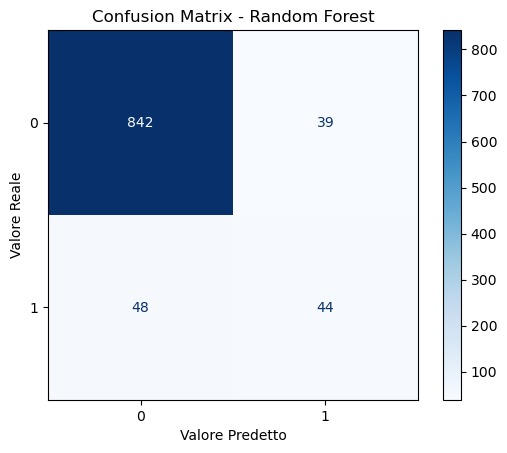

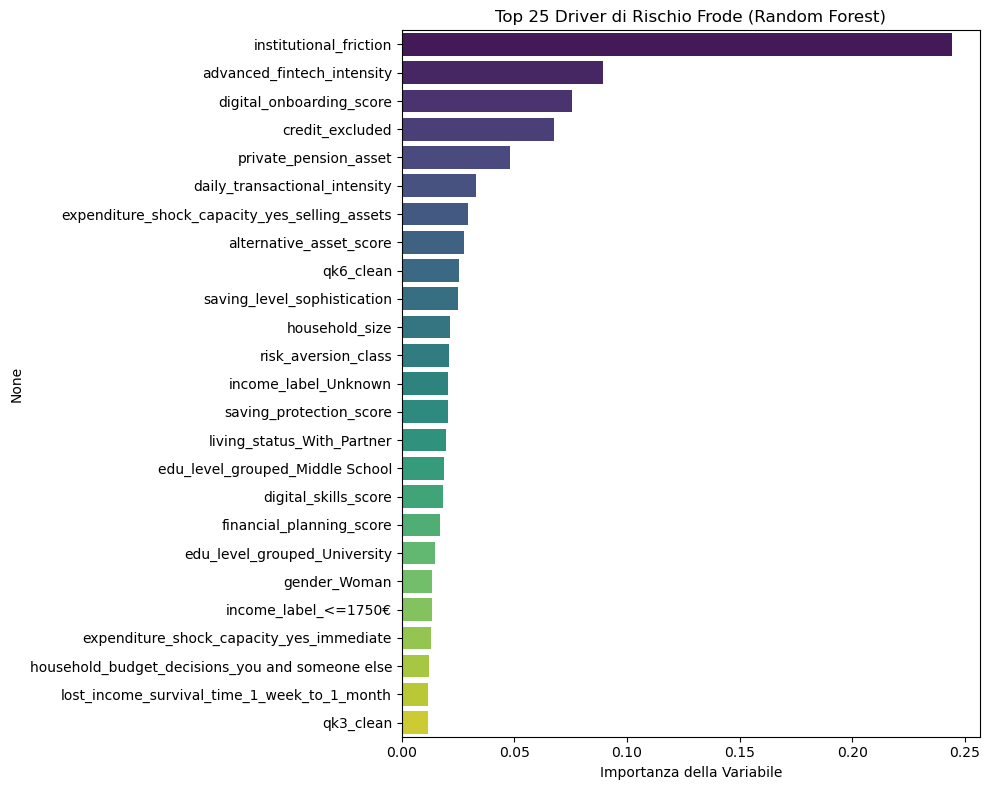

In [5]:
# ==========================================
# PARTE B: ADDESTRAMENTO MODELLI
# ==========================================
significant_features = [col for col in df.columns if col not in vars_to_excludee]
print(f"Variabili significative mantenute: {len(significant_features)}\n")
# 4. Preparazione Dati (Encoding e pulizia)
X_sig = df[significant_features].copy()
# Trasforma le categoriche in 0/1 (es. gender_Woman, age_group_50-59)
X_numeric = pd.get_dummies(X_sig, drop_first=True).astype(float)
# Imputiamo eventuali NaN rimasti con la mediana per non far rompere i modelli
X_numeric = X_numeric.fillna(X_numeric.median())

# Variabile Target (rimuoviamo eventuali NaN per sicurezza)
y = df[target].fillna(0)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_numeric, y, test_size=0.2, random_state=42, stratify=y)

# Oversampling con SMOTE (solo sul training set!)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# --- Modello 1: Classification Tree (Per la visualizzazione ad albero) ---
# Profondità max 4 per mantenerlo proiettabile in una slide
dt_model = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
dt_model.fit(X_train_smote, y_train_smote)

# --- Modello 2: Random Forest (Il motore predittivo ad alte performance) ---
rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X_train_smote, y_train_smote)

# Valutazione
y_pred_rf = rf_model.predict(X_test)
print("--- Performance RANDOM FOREST (Target 1 = Frode) ---")
print(classification_report(y_test, y_pred_rf))

# Confusion matrix

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Valore Predetto")
plt.ylabel("Valore Reale")
plt.show()

# ==========================================
# PARTE C: ESTRAZIONE INSIGHT PER IL PITCH
# ==========================================
plt.figure(figsize=(10, 8))
# Estraiamo le 25 variabili più importanti trovate dalla Random Forest
feature_imp = pd.Series(rf_model.feature_importances_, index=X_numeric.columns).sort_values(ascending=False).head(25)
sns.barplot(x=feature_imp, y=feature_imp.index, palette="viridis", hue=feature_imp.index, legend=False)
plt.title("Top 25 Driver di Rischio Frode (Random Forest)")
plt.xlabel("Importanza della Variabile")
plt.tight_layout()
plt.show()

In [6]:
# Estraiamo le top 12 variabili più importanti dal modello Random Forest
top_vars = pd.Series(rf_model.feature_importances_, index=X_numeric.columns).sort_values(ascending=False)

print("--- LE 'TITOLARI' PER IL PITCH AZIENDALE ---")
print(top_vars.head(15).to_string(float_format=lambda x: "{:.4f}".format(x)))

--- LE 'TITOLARI' PER IL PITCH AZIENDALE ---
institutional_friction                          0.2444
advanced_fintech_intensity                      0.0892
digital_onboarding_score                        0.0757
credit_excluded                                 0.0677
private_pension_asset                           0.0479
daily_transactional_intensity                   0.0327
expenditure_shock_capacity_yes_selling_assets   0.0292
alternative_asset_score                         0.0275
qk6_clean                                       0.0255
saving_level_sophistication                     0.0248
household_size                                  0.0214
risk_aversion_class                             0.0211
income_label_Unknown                            0.0207
saving_protection_score                         0.0204
living_status_With_Partner                      0.0196


In [29]:
pip install shap scikit-plot

  Using cached shap-0.51.0-cp313-cp313-win_amd64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached shap-0.51.0-cp313-cp313-win_amd64.whl (555 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)

   ------------- -------------------------- 1/3 [shap]
   ------------- -------------------------- 1/3 [shap]
   ------------- -------------------------- 1/3 [shap]
   ------------- -------------------------- 1/3 [shap]
   ------------- -------------------------- 1/3 [shap]
   ------------- -------------------------- 1/3 [shap]
   ------------- -------------------------- 1/3 [shap]
   ------------- -------------------------- 1/3 [shap]
   ------------- -------------------------- 1/3 [shap]
   ------------- -------------------------- 1/3 [shap]
   ------------- -------------------------- 1/3 [shap]
   ------------- -------------------------- 1/3 [shap]
   ------------- -------------------------- 1/3 [shap]
   ------------- -----------------------

--- TOP 15 VARIABILI SELEZIONATE (Academic Pipeline) ---
['institutional_friction', 'advanced_fintech_intensity', 'digital_onboarding_score', 'credit_excluded', 'private_pension_asset', 'daily_transactional_intensity', 'expenditure_shock_capacity_yes_selling_assets', 'alternative_asset_score', 'qk6_clean', 'saving_level_sophistication', 'household_size', 'risk_aversion_class', 'income_label_Unknown', 'saving_protection_score', 'living_status_With_Partner']

--- ODDS RATIO (LogReg sulle 15 feature) ---
                                      Feature  Odds Ratio
                       institutional_friction       6.616
                              credit_excluded       6.615
expenditure_shock_capacity_yes_selling_assets       1.980
                        private_pension_asset       1.819
                                    qk6_clean       1.599
                  saving_level_sophistication       1.393
                   advanced_fintech_intensity       1.286
                   living_sta

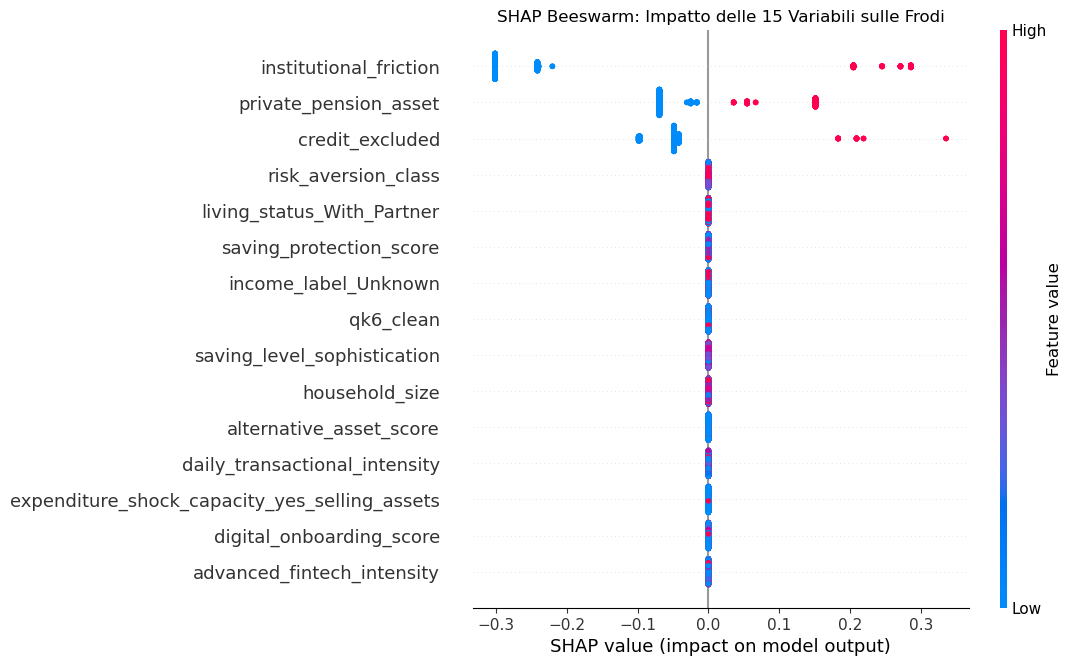

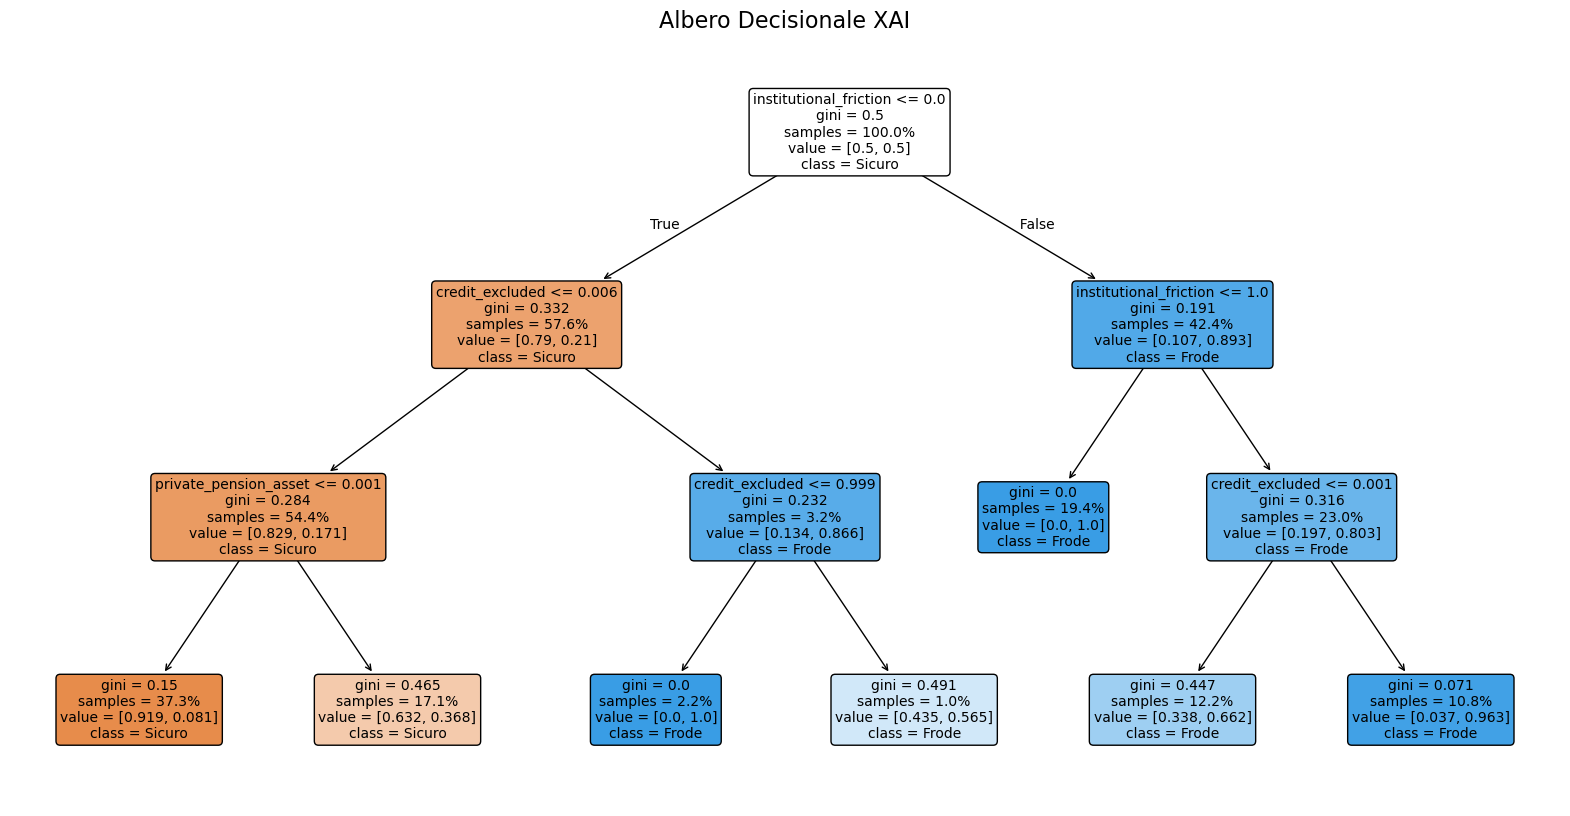

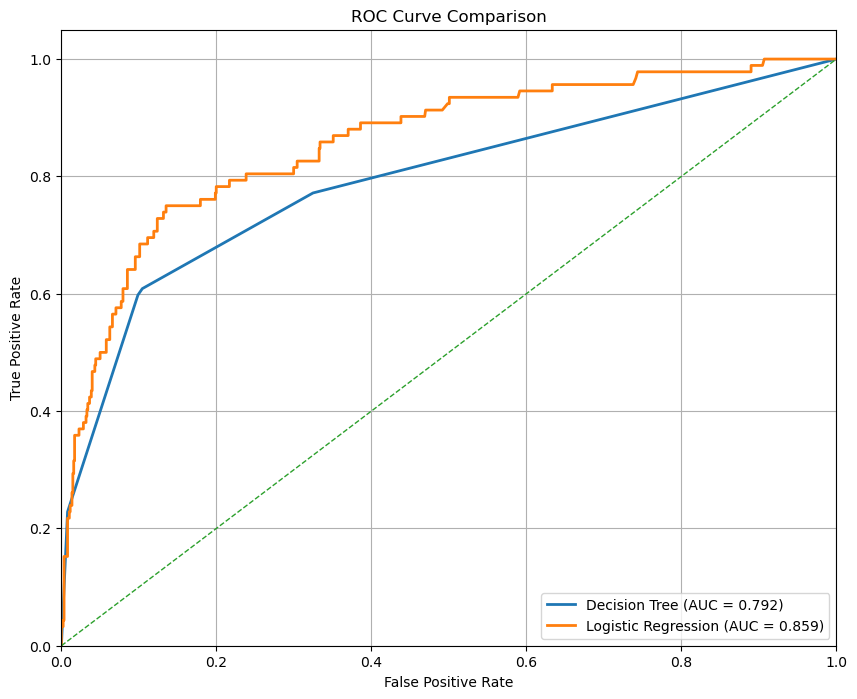

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import shap
import scipy
scipy.interp = np.interp
import scikitplot as skplt
from sklearn.metrics import roc_curve, auc

X_train, X_test, y_train, y_test = train_test_split(X_numeric, y, test_size=0.2, random_state=42, stratify=y)

# 3. SMOTE (Solo sul Training Set per evitare Data Leakage)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# =========================================================
# FASE 1: FEATURE SELECTION (Sul Training Bilanciato)
# =========================================================
rf_selector = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf_selector.fit(X_train_smote, y_train_smote)

# Estrazione delle top 15 variabili empiriche
feature_importances = pd.Series(rf_selector.feature_importances_, index=X_train_smote.columns)
top_15_features = feature_importances.sort_values(ascending=False).head(15).index.tolist()

print("--- TOP 15 VARIABILI SELEZIONATE (Academic Pipeline) ---")
print(top_15_features)

# =========================================================
# FASE 2: SUBSETTING E RETRAINING SULLE TOP 15
# =========================================================
# Riduciamo gli spazi dimensionali solo alle variabili elette
X_train_smote_15 = X_train_smote[top_15_features]
X_train_15 = X_train[top_15_features]
X_test_15 = X_test[top_15_features]

# --- MODELLO A: REGRESSIONE LOGISTICA (Per Odds Ratio) ---
log_reg = LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')
log_reg.fit(X_train_15, y_train)

odds_ratios = np.exp(log_reg.coef_[0])
odds_df = pd.DataFrame({
    'Feature': top_15_features,
    'Odds Ratio': odds_ratios
}).sort_values(by='Odds Ratio', ascending=False)
print("\n--- ODDS RATIO (LogReg sulle 15 feature) ---")
print(odds_df.to_string(index=False, float_format=lambda x: "{:.3f}".format(x)))

# --- MODELLO B: ALBERO DECISIONALE (Per le slide di Business) ---
dt_model = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
dt_model.fit(X_train_smote_15, y_train_smote)

# =========================================================
# FASE 3: VALUTAZIONE (Sul Test Set originale imperturbato) ed XAI
# =========================================================
y_pred_dt = dt_model.predict(X_test_15)

# Confusion Matrix
print("\n--- CONFUSION MATRIX (Test Set Reale) ---")
print(confusion_matrix(y_test, y_pred_dt))
print("\n--- REPORT DI CLASSIFICAZIONE ---")
print(classification_report(y_test, y_pred_dt))

# XAI: SHAP Beeswarm Plot (Sull'Albero e sul Test Set)
print("\nGenerazione SHAP Values...")
explainer = shap.TreeExplainer(dt_model)
shap_values = explainer(X_test_15)

plt.figure()
plt.title("SHAP Beeswarm: Impatto delle 15 Variabili sulle Frodi")
try:
    shap.plots.beeswarm(shap_values[:, :, 1], max_display=15)
except:
    shap.plots.beeswarm(shap_values, max_display=15)

# Visualizzazione Albero
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=top_15_features, class_names=['Sicuro', 'Frode'], 
          filled=True, rounded=True, proportion=True, fontsize=10)
plt.title("Albero Decisionale XAI", fontsize=16)
plt.show()

# ============================
# ROC CURVE - Confronto Modelli
# ============================

# Probabilità classe positiva (classe 1 = frode)
y_pred_dt_proba = dt_model.predict_proba(X_test_15)[:, 1]
y_pred_log_proba = log_reg.predict_proba(X_test_15)[:, 1]

# Calcolo ROC
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_dt_proba)
roc_auc_dt = auc(fpr_dt, tpr_dt)

fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_log_proba)
roc_auc_log = auc(fpr_log, tpr_log)

# Plot
plt.figure(figsize=(10, 8))

plt.plot(
    fpr_dt,
    tpr_dt,
    linewidth=2,
    label=f'Decision Tree (AUC = {roc_auc_dt:.3f})'
)

plt.plot(
    fpr_log,
    tpr_log,
    linewidth=2,
    label=f'Logistic Regression (AUC = {roc_auc_log:.3f})'
)

# Random classifier baseline
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

In [7]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import GridSearchCV

# 1. Prepariamo il training set puro (PRIMA dello SMOTE) filtrato per le 15 variabili titolari.
# Assumiamo che X_train, y_train, X_test e top_15_features esistano già nel tuo environment.
X_train_15 = X_train[top_15_features]
X_test_15 = X_test[top_15_features]

# ==========================================
# GRID SEARCH PER ALBERO DECISIONALE (Trasparenza)
# ==========================================
# Creiamo la pipeline: SMOTE viene applicato dinamicamente dentro ogni fold
dt_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('dt', DecisionTreeClassifier(class_weight='balanced', random_state=42))
])

# Definiamo la griglia dei parametri. 
# Manteniamo max_depth tra 3 e 5 per non creare un albero gigante e illeggibile nelle slide.
param_grid_dt = {
    'dt__max_depth': [3, 4, 5],
    'dt__min_samples_split': [2, 5, 10],
    'dt__min_samples_leaf': [1, 5, 10],
    'dt__criterion': ['gini', 'entropy']
}

print("Avvio Grid Search per Decision Tree...")
# scoring='recall' perché vogliamo che il modello scelga i parametri che beccano più frodi possibili
grid_dt = GridSearchCV(dt_pipe, param_grid_dt, cv=5, scoring='recall', n_jobs=-1)
grid_dt.fit(X_train_15, y_train)

print("\n--- Migliori Parametri DECISION TREE ---")
print(grid_dt.best_params_)
print(f"Miglior Recall (in Cross-Validation): {grid_dt.best_score_:.3f}")


# ==========================================
# GRID SEARCH PER RANDOM FOREST (Performance Pura)
# ==========================================
rf_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

# Griglia più ampia per la Random Forest, dato che non dobbiamo stamparla visivamente
param_grid_rf = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [4, 6, 8, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__max_features': ['sqrt', 'log2']
}

print("\nAvvio Grid Search per Random Forest (potrebbe richiedere qualche minuto)...")
grid_rf = GridSearchCV(rf_pipe, param_grid_rf, cv=5, scoring='recall', n_jobs=-1)
grid_rf.fit(X_train_15, y_train)

print("\n--- Migliori Parametri RANDOM FOREST ---")
print(grid_rf.best_params_)
print(f"Miglior Recall (in Cross-Validation): {grid_rf.best_score_:.3f}")


# ==========================================
# VALUTAZIONE FINALE DEL CAMPIONE (SUL TEST SET)
# ==========================================
# Estraiamo il miglior modello trovato dalla griglia
best_rf = grid_rf.best_estimator_

# Lo testiamo sulla nostra cassaforte: il Test Set incontaminato
y_pred_best_rf = best_rf.predict(X_test_15)

print("\n" + "="*50)
print("PERFORMANCE DEL MIGLIOR RANDOM FOREST SUL TEST SET")
print("="*50)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_rf))

Avvio Grid Search per Decision Tree...

--- Migliori Parametri DECISION TREE ---
{'dt__criterion': 'gini', 'dt__max_depth': 3, 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2}
Miglior Recall (in Cross-Validation): 0.609

Avvio Grid Search per Random Forest (potrebbe richiedere qualche minuto)...

--- Migliori Parametri RANDOM FOREST ---
{'rf__max_depth': 4, 'rf__max_features': 'sqrt', 'rf__min_samples_split': 10, 'rf__n_estimators': 200}
Miglior Recall (in Cross-Validation): 0.675

PERFORMANCE DEL MIGLIOR RANDOM FOREST SUL TEST SET

Confusion Matrix:
[[789  92]
 [ 32  60]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.90      0.93       881
           1       0.39      0.65      0.49        92

    accuracy                           0.87       973
   macro avg       0.68      0.77      0.71       973
weighted avg       0.91      0.87      0.89       973



--- Performance RANDOM FOREST (Target 1 = Frode) ---
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       881
           1       0.45      0.58      0.50        92

    accuracy                           0.89       973
   macro avg       0.70      0.75      0.72       973
weighted avg       0.91      0.89      0.90       973



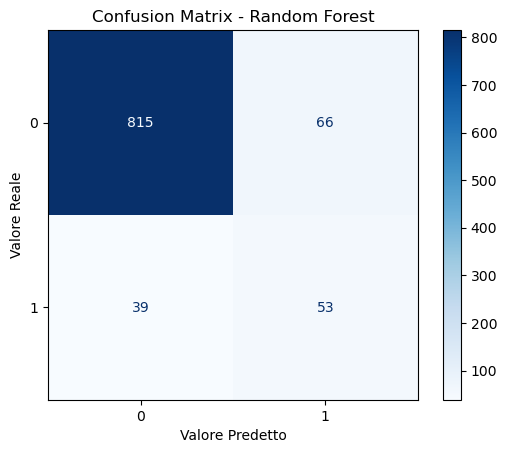

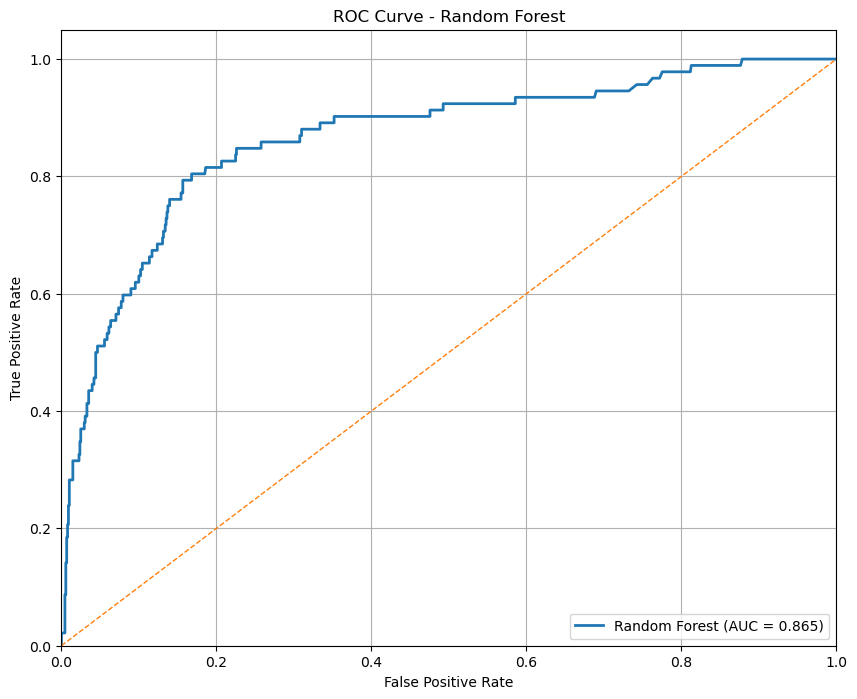

In [17]:
#random forest con i migliori parametri trovati
rf_best_model = RandomForestClassifier(n_estimators=grid_rf.best_params_['rf__n_estimators'], 
                                  max_depth=grid_rf.best_params_['rf__max_depth'],
                                    min_samples_split=grid_rf.best_params_['rf__min_samples_split'],
                                    max_features=grid_rf.best_params_['rf__max_features'],
                                    random_state=42)
rf_best_model.fit(X_train_smote_15, y_train_smote)
y_pred_best_rf = rf_best_model.predict(X_test_15)
print("--- Performance RANDOM FOREST (Target 1 = Frode) ---")
print(classification_report(y_test, y_pred_best_rf))

# Confusion matrix

cm = confusion_matrix(y_test, y_pred_best_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Valore Predetto")
plt.ylabel("Valore Reale")
plt.show()
# ============================
# ROC CURVE - RANDOM FOREST
# ============================

# Probabilità classe positiva (1 = frode)
y_pred_rf_proba = rf_best_model.predict_proba(X_test_15)[:, 1]

# Calcolo curva ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf_proba)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot
plt.figure(figsize=(10, 8))

plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f'Random Forest (AUC = {roc_auc_rf:.3f})'
)

# Baseline casuale
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

## Proposta ChatGPT ##


LOGISTIC RESULTS
ROC AUC: 0.8566722597838425
PR AUC: 0.4497310397718738
              precision    recall  f1-score   support

           0       0.98      0.68      0.80       881
           1       0.22      0.89      0.36        92

    accuracy                           0.70       973
   macro avg       0.60      0.78      0.58       973
weighted avg       0.91      0.70      0.76       973

[[596 285]
 [ 10  82]]


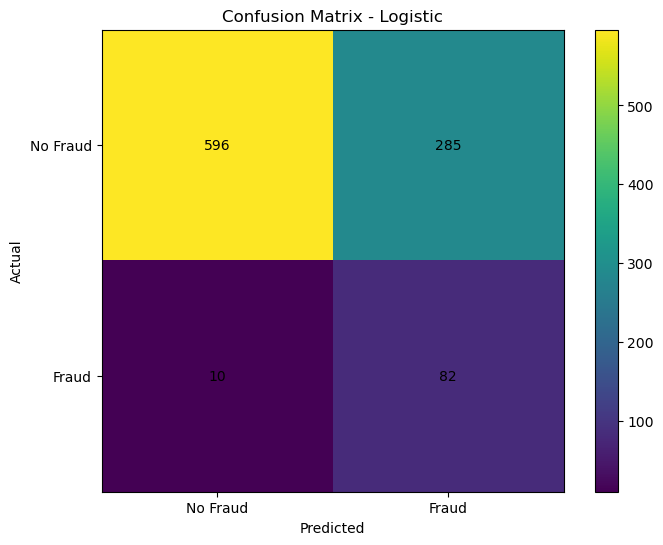

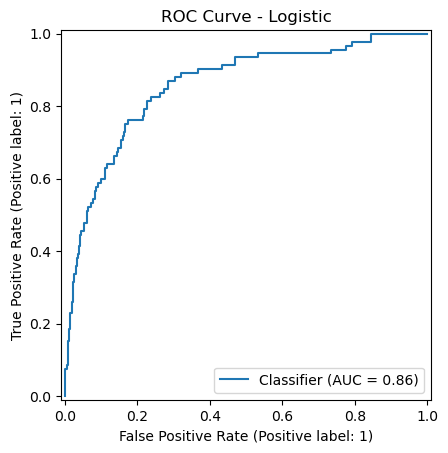

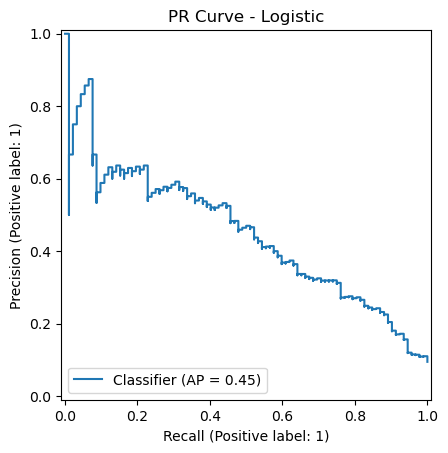


TOP RISK FEATURES
                                              feature      coef
41  cat__expenditure_shock_capacity_yes_selling_as...  0.572432
17                 num__daily_transactional_intensity  0.412659
23                                     num__qk6_clean  0.402974
2                    num__saving_level_sophistication  0.398192
38  cat__household_budget_decisions_you and someon...  0.327417
29           num__knowledge_financial_privacy_digital  0.322404
51   cat__lost_income_survival_time_1_week_to_1_month  0.318054
93                       cat__income_label_1751-2900€  0.311752
15                      num__digital_onboarding_score  0.298098
83                 cat__edu_level_grouped_High School  0.273709
4                          num__private_pension_asset  0.256936
18                    num__advanced_fintech_intensity  0.247775
84               cat__edu_level_grouped_Middle School  0.229254
60                       cat__gap_class_Overconfident  0.227666
42          cat__reti

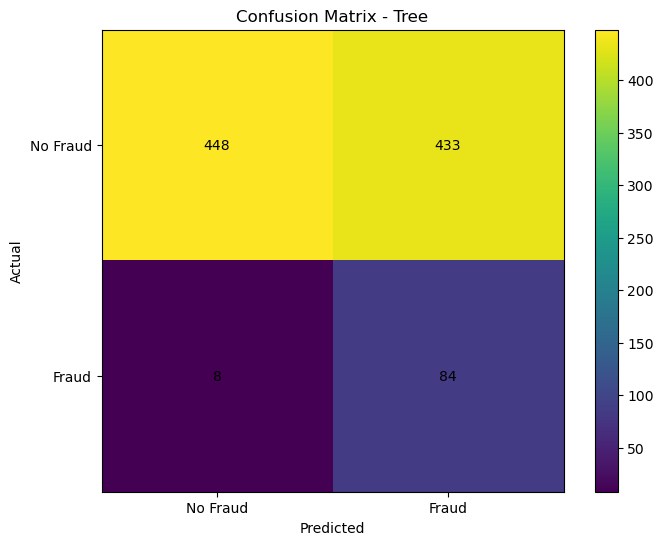

TREE RESULTS
ROC AUC: 0.8263707249666881
PR AUC: 0.3169484299758639


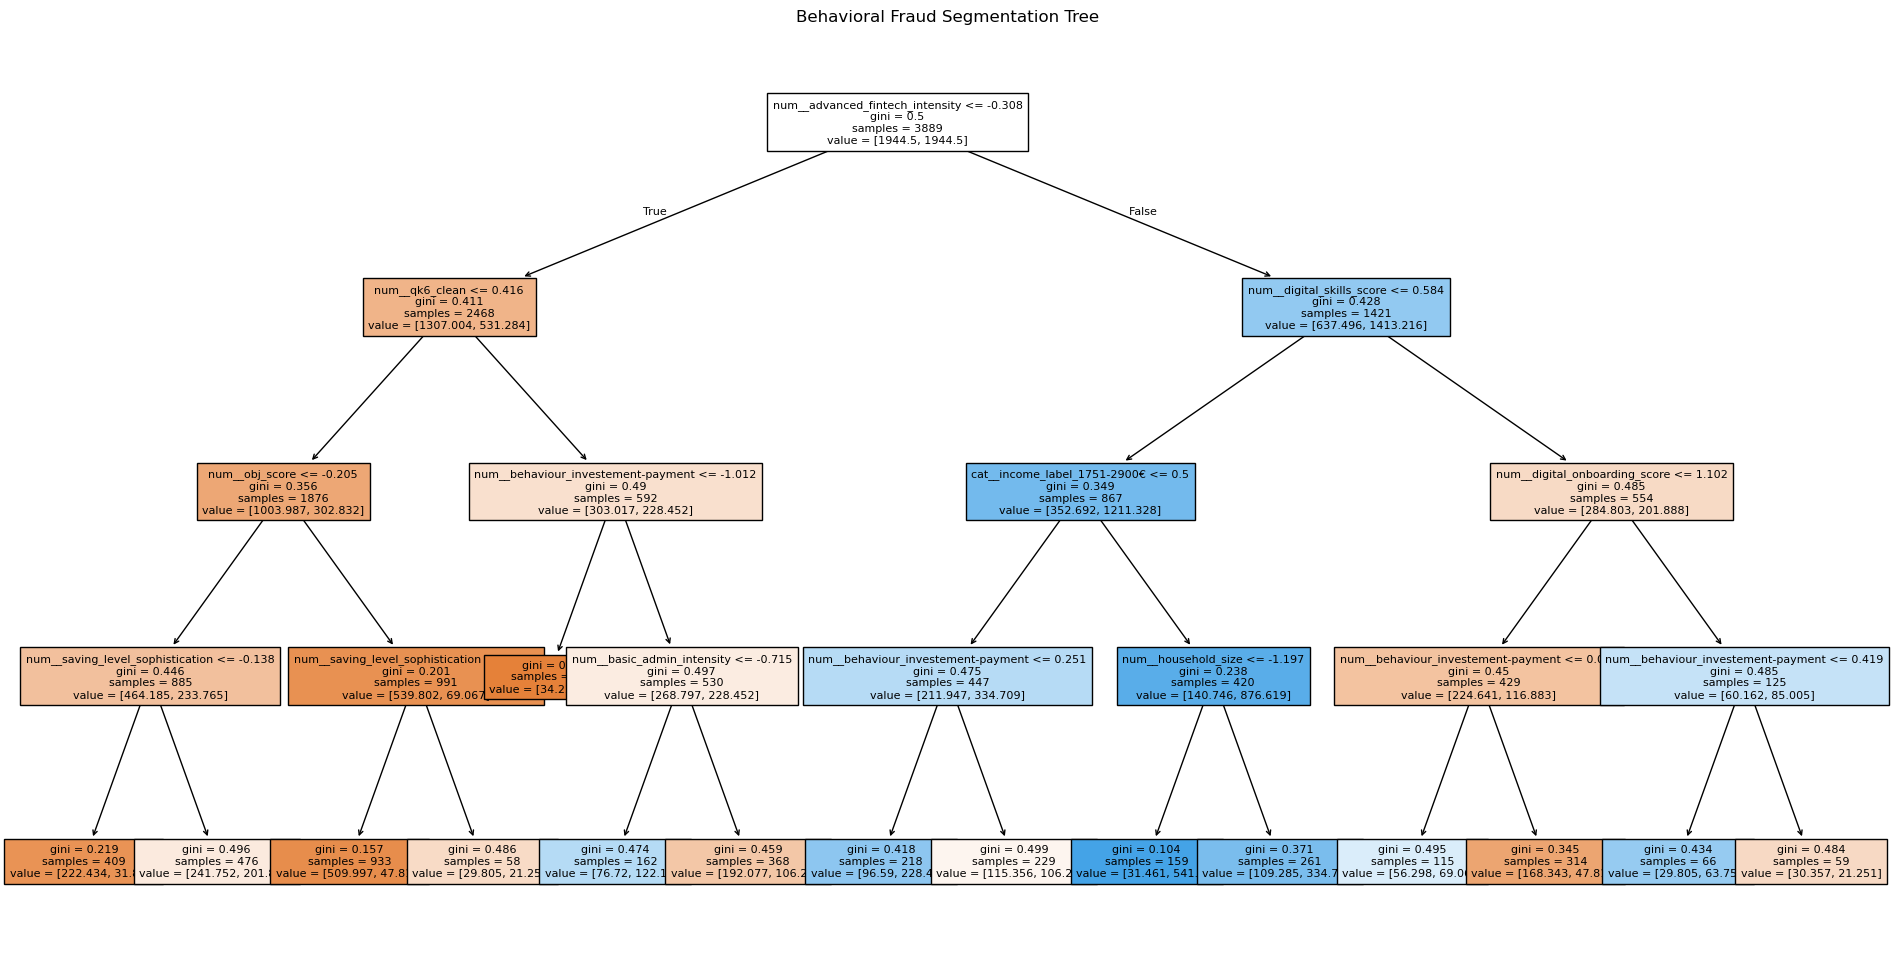


LIFT BY DECILE
decile
0    0.091837
1    0.092784
2    0.134021
3    0.134021
4    0.071429
5    0.061856
6    0.061856
7    0.061856
8    0.134021
9    0.102041
Name: actual, dtype: float64


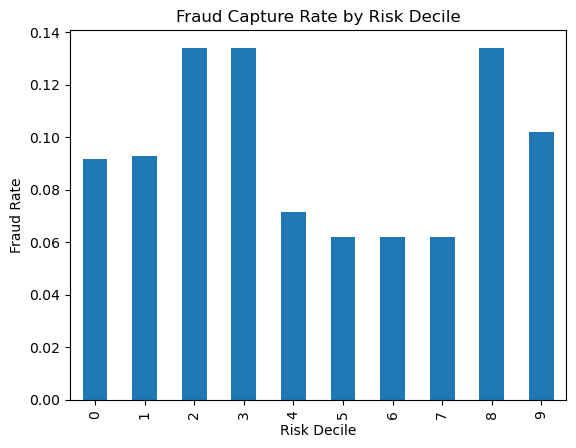


OVERCONFIDENCE x DIGITAL INTENSITY
advanced_fintech_intensity  (-0.001, 2.0]  (2.0, 6.0]
gap_class                                            
Calibrated                       0.063559    0.216667
Overconfident                    0.070064    0.204301
Underconfident                   0.058534    0.251174


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# ==========================
# 1. LOAD DATA
# ==========================
df_gpt = pd.read_csv('C:\\Users\\HP\\Desktop\\data_science\\primo_anno\\DSLab\\DS_Lab\\cleaned_df2.csv')

TARGET = 'cyber_fraud_victim'

DROP_COLS = [
    TARGET,
    'institutional_friction',
    'credit_excluded'
]

X = df_gpt.drop(columns=DROP_COLS, errors='ignore')
y = df_gpt[TARGET]

# ==========================
# 2. FEATURE TYPES
# ==========================
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category','bool']).columns.tolist()

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

# ==========================
# 3. SPLIT
# ==========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ==========================
# 4. LOGISTIC REGRESSION
# ==========================
log_model = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(
        class_weight='balanced',
        penalty='l1',
        solver='liblinear',
        max_iter=5000
    ))
])

log_model.fit(X_train, y_train)

log_probs = log_model.predict_proba(X_test)[:,1]
log_preds = (log_probs > 0.35).astype(int)

print('\nLOGISTIC RESULTS')
print('ROC AUC:', roc_auc_score(y_test, log_probs))
print('PR AUC:', average_precision_score(y_test, log_probs))
print(classification_report(y_test, log_preds))
cm_log = confusion_matrix(y_test, log_preds)
print(cm_log)
plt.figure(figsize=(8,6))
plt.imshow(cm_log)
plt.title('Confusion Matrix - Logistic')
plt.colorbar()
plt.xticks([0,1],['No Fraud','Fraud'])
plt.yticks([0,1],['No Fraud','Fraud'])
for i in range(2):
    for j in range(2):
        plt.text(j,i,str(cm_log[i,j]),ha='center',va='center')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

RocCurveDisplay.from_predictions(y_test, log_probs)
plt.title('ROC Curve - Logistic')
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, log_probs)
plt.title('PR Curve - Logistic')
plt.show()

# ==========================
# 5. COEFFICIENT IMPORTANCE
# ==========================
feature_names = log_model.named_steps['prep'].get_feature_names_out()
coefs = log_model.named_steps['clf'].coef_[0]

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coefs
}).sort_values('coef', ascending=False)

print('\nTOP RISK FEATURES')
print(coef_df.head(15))

print('\nTOP PROTECTIVE FEATURES')
print(coef_df.tail(15))

# ==========================
# 6. DECISION TREE
# ==========================
tree_model = Pipeline([
    ('prep', preprocessor),
    ('clf', DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=50,
        class_weight='balanced',
        random_state=42
    ))
])

tree_model.fit(X_train, y_train)

tree_probs = tree_model.predict_proba(X_test)[:,1]

tree_preds = (tree_probs > 0.35).astype(int)
cm_tree = confusion_matrix(y_test, tree_preds)
plt.figure(figsize=(8,6))
plt.imshow(cm_tree)
plt.title('Confusion Matrix - Tree')
plt.colorbar()
plt.xticks([0,1],['No Fraud','Fraud'])
plt.yticks([0,1],['No Fraud','Fraud'])
for i in range(2):
    for j in range(2):
        plt.text(j,i,str(cm_tree[i,j]),ha='center',va='center')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print('TREE RESULTS')
print('ROC AUC:', roc_auc_score(y_test, tree_probs))
print('PR AUC:', average_precision_score(y_test, tree_probs))

plt.figure(figsize=(24,12))
plot_tree(
    tree_model.named_steps['clf'],
    max_depth=4,
    filled=True,
    feature_names=feature_names,
    fontsize=8
)
plt.title('Behavioral Fraud Segmentation Tree')
plt.show()

# ==========================
# 7. BUSINESS LIFT
# ==========================
results = pd.DataFrame({
    'actual': y_test,
    'score': log_probs
})

results = results.sort_values('score', ascending=False)
results['decile'] = pd.qcut(results.index, 10, labels=False)

lift = results.groupby('decile')['actual'].mean()
print('\nLIFT BY DECILE')
print(lift)

lift.plot(kind='bar')
plt.title('Fraud Capture Rate by Risk Decile')
plt.xlabel('Risk Decile')
plt.ylabel('Fraud Rate')
plt.show()

# ==========================
# 8. INTERACTION TEST
# ==========================
if 'advanced_fintech_intensity' in X.columns and 'gap_class' in X.columns:
    interaction = pd.crosstab(
        X['gap_class'],
        pd.qcut(X['advanced_fintech_intensity'],4, duplicates='drop'),
        values=y,
        aggfunc='mean'
    )
    print('\nOVERCONFIDENCE x DIGITAL INTENSITY')
    print(interaction)
